# IT2011 - Artificial Intelligence and Machine Learning

## Progress Review I
### Member 01 - Data Cleaning and Missing Data Handling

**Dataset:** Breast Cancer Wisconsin (Original)

**Main Responsibility:**
- Dataset investigation
- Missing data handling
- Duplicate investigation
- Data quality validation

In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================
# STEP 1 - Import required libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ============================================
# STEP 2 - Load the original dataset
# ============================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

df = pd.read_csv(url, header=None)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (699, 11)


In [4]:
# ============================================
# STEP 3 - Assign meaningful column names
# ============================================

columns = [
    "Sample_ID",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

df.columns = columns

print("Column names assigned successfully.")
print(df.columns.tolist())

Column names assigned successfully.
['Sample_ID', 'Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']


In [5]:
# ============================================
# STEP 4 - Inspect the dataset
# ============================================

print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

First 5 rows:


,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2



Dataset Shape:
(699, 11)

Data Types:
Sample_ID                      int64
Clump_Thickness                int64
Uniformity_Cell_Size           int64
Uniformity_Cell_Shape          int64
Marginal_Adhesion              int64
Single_Epithelial_Cell_Size    int64
Bare_Nuclei                      str
Bland_Chromatin                int64
Normal_Nucleoli                int64
Mitoses                        int64
Class                          int64
dtype: object


In [6]:
# ============================================
# STEP 5 - Investigate missing values
# ============================================

print("Number of '?' values in each column:")
print((df == "?").sum())

Number of '?' values in each column:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [7]:
# ============================================
# STEP 6 - Convert '?' values to NaN
# ============================================

df["Bare_Nuclei"] = df["Bare_Nuclei"].replace("?", np.nan)

df["Bare_Nuclei"] = pd.to_numeric(df["Bare_Nuclei"])

print("Data type of Bare_Nuclei:")
print(df["Bare_Nuclei"].dtype)

print("\nMissing values after conversion:")
print(df.isnull().sum())

Data type of Bare_Nuclei:
float64

Missing values after conversion:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [8]:
# ============================================
# STEP 7 - Analyze rows with missing Bare_Nuclei
# ============================================

missing_rows = df[df["Bare_Nuclei"].isnull()]

print("Number of rows with missing Bare_Nuclei:")
print(len(missing_rows))

print("\nClass distribution among missing rows:")
print(missing_rows["Class"].value_counts())

missing_percentage = (
    df["Bare_Nuclei"].isnull().sum() / len(df)
) * 100

print("\nPercentage of missing Bare_Nuclei values:")
print(f"{missing_percentage:.2f}%")

Number of rows with missing Bare_Nuclei:
16

Class distribution among missing rows:
Class
2    14
4     2
Name: count, dtype: int64

Percentage of missing Bare_Nuclei values:
2.29%


In [9]:
# ============================================
# STEP 8 - Analyze Bare_Nuclei distribution
# ============================================

print("Descriptive statistics for Bare_Nuclei:")
print(df["Bare_Nuclei"].describe())

print("\nFrequency of Bare_Nuclei values:")
print(df["Bare_Nuclei"].value_counts().sort_index())

Descriptive statistics for Bare_Nuclei:
count    683.000000
mean       3.544656
std        3.643857
min        1.000000
25%        1.000000
50%        1.000000
75%        6.000000
max       10.000000
Name: Bare_Nuclei, dtype: float64

Frequency of Bare_Nuclei values:
Bare_Nuclei
1.0     402
2.0      30
3.0      28
4.0      19
5.0      30
6.0       4
7.0       8
8.0      21
9.0       9
10.0    132
Name: count, dtype: int64


In [10]:
# ============================================
# STEP 9 - Handle missing values using median
# ============================================

bare_nuclei_median = df["Bare_Nuclei"].median()

print("Median of Bare_Nuclei:", bare_nuclei_median)

df["Bare_Nuclei"] = df["Bare_Nuclei"].fillna(
    bare_nuclei_median
)

print("\nMissing values after median imputation:")
print(df.isnull().sum())

Median of Bare_Nuclei: 1.0

Missing values after median imputation:
Sample_ID                      0
Clump_Thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [11]:
# ============================================
# STEP 10 - Investigate exact duplicate rows
# ============================================

# Create a temporary copy for duplicate checking
df_duplicate_check = df.copy()

# Check completely identical rows
exact_duplicates = df_duplicate_check.duplicated().sum()

print("Number of exact duplicate rows:")
print(exact_duplicates)

Number of exact duplicate rows:
9


In [12]:
# ============================================
# STEP 11 - Remove exact duplicate observations
# ============================================

before_duplicates = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after_duplicates = len(df)

print("Rows before removing duplicates:", before_duplicates)
print("Rows after removing duplicates:", after_duplicates)
print("Exact duplicate rows remaining:", df.duplicated().sum())

Rows before removing duplicates: 699
Rows after removing duplicates: 690
Exact duplicate rows remaining: 0


In [13]:
# ============================================
# STEP 12 - Analyze Bare_Nuclei distribution
# ============================================

print("Descriptive statistics for Bare_Nuclei:")
print(df["Bare_Nuclei"].describe())

print("\nMedian of Bare_Nuclei:")
print(df["Bare_Nuclei"].median())

Descriptive statistics for Bare_Nuclei:
count    690.000000
mean       3.482609
std        3.617064
min        1.000000
25%        1.000000
50%        1.000000
75%        5.000000
max       10.000000
Name: Bare_Nuclei, dtype: float64

Median of Bare_Nuclei:
1.0


In [14]:
# ============================================
# STEP 13 - Final data quality check
# ============================================

print("Final dataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nExact duplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Final dataset shape:
(690, 11)

Missing values:
Sample_ID                      0
Clump_Thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

Exact duplicate rows:
0

Data types:
Sample_ID                        int64
Clump_Thickness                  int64
Uniformity_Cell_Size             int64
Uniformity_Cell_Shape            int64
Marginal_Adhesion                int64
Single_Epithelial_Cell_Size      int64
Bare_Nuclei                    float64
Bland_Chromatin                  int64
Normal_Nucleoli                  int64
Mitoses                          int64
Class                            int64
dtype: object


## Data Cleaning Summary

- The original dataset contained 699 observations and 11 columns.
- 16 missing values were identified in the Bare_Nuclei feature.
- The missing values were represented by `?`.
- `?` values were converted to NaN and Bare_Nuclei was converted to numeric.
- Exact duplicate observations were investigated and removed.
- 8 exact duplicate observations were removed.
- The dataset was reduced from 699 to 691 observations.
- Bare_Nuclei missing values were handled using median imputation.
- The final cleaned dataset contained no missing values and no exact duplicate rows.

In [15]:
# ============================================
# STEP 14 - Save cleaned outputs
# ============================================

df.to_csv(
    "results/outputs/cleaned_dataset.csv",
    index=False
)

missing_summary = df.isnull().sum().reset_index()
missing_summary.columns = ["Column", "Missing_Values"]

missing_summary.to_csv(
    "results/outputs/missing_value_summary.csv",
    index=False
)

print("Cleaned dataset and missing-value summary saved successfully.")

Cleaned dataset and missing-value summary saved successfully.


# Final Evaluation – Individual Model

## Member 01 – Decision Tree Classification

### Objective

The objective is to classify breast-cancer observations into:

- **0 – Benign**
- **1 – Malignant**

The Decision Tree model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

Particular attention is given to recall and false negatives because a false negative
represents a malignant observation incorrectly classified as benign.

In [35]:
# ============================================
# FINAL EVALUATION - STEP 1
# Import modelling libraries
# ============================================

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("Final evaluation libraries imported successfully.")

Final evaluation libraries imported successfully.


In [36]:
# ============================================
# Check cleaned dataset before modelling
# ============================================

print("df exists:", "df" in globals())

if "df" in globals():
    print("Dataset shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst 5 rows:")
    display(df.head())

df exists: True
Dataset shape: (690, 11)

Columns:
['Sample_ID', 'Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']

First 5 rows:


,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


In [37]:
# ============================================
# FINAL EVALUATION - STEP 2
# Prepare features and target
# ============================================

# Remove the identifier because Sample_ID is not a predictive feature
X = df.drop(columns=["Sample_ID", "Class"]).copy()

# Convert target:
# 2 = Benign  -> 0
# 4 = Malignant -> 1
y = df["Class"].map({
    2: 0,
    4: 1
})

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Feature matrix shape: (690, 9)
Target shape: (690,)

Target distribution:
Class
0    452
1    238
Name: count, dtype: int64


In [19]:
# ============================================
# FINAL EVALUATION - STEP 3
# Train/Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 552
Testing samples : 138

Training class distribution:
Class
0    362
1    190
Name: count, dtype: int64

Testing class distribution:
Class
0    90
1    48
Name: count, dtype: int64


In [20]:
# ============================================
# FINAL EVALUATION - STEP 4
# Baseline Decision Tree
# ============================================

decision_tree_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Baseline Decision Tree trained successfully.")

Baseline Decision Tree trained successfully.


In [21]:
# ============================================
# FINAL EVALUATION - STEP 5
# Baseline Decision Tree Evaluation
# ============================================

y_pred_dt_baseline = decision_tree_pipeline.predict(X_test)

y_prob_dt_baseline = decision_tree_pipeline.predict_proba(
    X_test
)[:, 1]

dt_baseline_accuracy = accuracy_score(
    y_test,
    y_pred_dt_baseline
)

dt_baseline_precision = precision_score(
    y_test,
    y_pred_dt_baseline
)

dt_baseline_recall = recall_score(
    y_test,
    y_pred_dt_baseline
)

dt_baseline_f1 = f1_score(
    y_test,
    y_pred_dt_baseline
)

dt_baseline_roc_auc = roc_auc_score(
    y_test,
    y_prob_dt_baseline
)

dt_baseline_cm = confusion_matrix(
    y_test,
    y_pred_dt_baseline
)

tn, fp, fn, tp = dt_baseline_cm.ravel()

print("Decision Tree - Baseline Results\n")

print(f"Accuracy : {dt_baseline_accuracy:.4f}")
print(f"Precision: {dt_baseline_precision:.4f}")
print(f"Recall   : {dt_baseline_recall:.4f}")
print(f"F1-score : {dt_baseline_f1:.4f}")
print(f"ROC-AUC  : {dt_baseline_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(dt_baseline_cm)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Decision Tree - Baseline Results

Accuracy : 0.9203
Precision: 0.9111
Recall   : 0.8542
F1-score : 0.8817
ROC-AUC  : 0.9049

Confusion Matrix:
[[86  4]
 [ 7 41]]

TN: 86
FP: 4
FN: 7
TP: 41


## Cross-Validation of the Baseline Decision Tree

A 5-fold Stratified Cross-Validation approach is used to evaluate the stability
and generalization ability of the baseline Decision Tree.

Stratification maintains approximately the same benign/malignant class
distribution in each fold.

The evaluated metrics are Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [38]:
# ============================================
# FINAL EVALUATION - STEP 6
# 5-Fold Stratified Cross-Validation
# ============================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results_dt = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Decision Tree - Baseline Cross-Validation Results\n")

for metric in scoring:
    values = cv_results_dt[f"test_{metric}"]

    print(
        f"{metric.upper():10s}: "
        f"{values.mean():.4f} ± {values.std():.4f}"
    )

Decision Tree - Baseline Cross-Validation Results

ACCURACY  : 0.9511 ± 0.0240
PRECISION : 0.9405 ± 0.0311
RECALL    : 0.9158 ± 0.0453
F1        : 0.9277 ± 0.0355
ROC_AUC   : 0.9427 ± 0.0287


## Decision Tree Hyperparameter Tuning

GridSearchCV is used to test multiple Decision Tree configurations and identify
the best hyperparameter combination.

The following hyperparameters are tuned:

- `criterion` – function used to measure split quality.
- `max_depth` – maximum depth of the tree.
- `min_samples_split` – minimum samples required to split an internal node.
- `min_samples_leaf` – minimum samples required in a leaf node.
- `class_weight` – controls the importance assigned to each class.

The search uses 5-fold Stratified Cross-Validation and F1-score as the primary
optimization metric.

In [39]:
# ============================================
# FINAL EVALUATION - STEP 7
# Decision Tree Hyperparameter Grid
# ============================================

dt_param_grid = {

    "model__criterion": [
        "gini",
        "entropy"
    ],

    "model__max_depth": [
        None,
        3,
        5,
        7,
        10
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}

# Calculate how many configurations will be tested
number_of_combinations = (
    len(dt_param_grid["model__criterion"]) *
    len(dt_param_grid["model__max_depth"]) *
    len(dt_param_grid["model__min_samples_split"]) *
    len(dt_param_grid["model__min_samples_leaf"]) *
    len(dt_param_grid["model__class_weight"])
)

print("Hyperparameter combinations:", number_of_combinations)
print("CV folds:", 5)
print(
    "Total model fits:",
    number_of_combinations * 5
)

Hyperparameter combinations: 180
CV folds: 5
Total model fits: 900


In [40]:
# ============================================
# FINAL EVALUATION - STEP 8
# GridSearchCV
# ============================================

dt_grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

dt_grid_search.fit(
    X_train,
    y_train
)

print("Decision Tree tuning completed.\n")

print("Best Parameters:")
print(dt_grid_search.best_params_)

print(
    "\nBest Cross-Validation F1:",
    round(dt_grid_search.best_score_, 4)
)

Decision Tree tuning completed.

Best Parameters:
{'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}

Best Cross-Validation F1: 0.9375


In [41]:
# ============================================
# FINAL EVALUATION - STEP 9
# Tuned Decision Tree Evaluation
# ============================================

best_dt_model = dt_grid_search.best_estimator_

y_pred_dt_tuned = best_dt_model.predict(X_test)

y_prob_dt_tuned = best_dt_model.predict_proba(
    X_test
)[:, 1]

dt_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_dt_tuned
)

dt_tuned_precision = precision_score(
    y_test,
    y_pred_dt_tuned
)

dt_tuned_recall = recall_score(
    y_test,
    y_pred_dt_tuned
)

dt_tuned_f1 = f1_score(
    y_test,
    y_pred_dt_tuned
)

dt_tuned_roc_auc = roc_auc_score(
    y_test,
    y_prob_dt_tuned
)

dt_tuned_cm = confusion_matrix(
    y_test,
    y_pred_dt_tuned
)

tn_tuned, fp_tuned, fn_tuned, tp_tuned = dt_tuned_cm.ravel()

print("Decision Tree - Tuned Results\n")

print(f"Accuracy : {dt_tuned_accuracy:.4f}")
print(f"Precision: {dt_tuned_precision:.4f}")
print(f"Recall   : {dt_tuned_recall:.4f}")
print(f"F1-score : {dt_tuned_f1:.4f}")
print(f"ROC-AUC  : {dt_tuned_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(dt_tuned_cm)

print("\nTN:", tn_tuned)
print("FP:", fp_tuned)
print("FN:", fn_tuned)
print("TP:", tp_tuned)

Decision Tree - Tuned Results

Accuracy : 0.9275
Precision: 0.8800
Recall   : 0.9167
F1-score : 0.8980
ROC-AUC  : 0.9402

Confusion Matrix:
[[84  6]
 [ 4 44]]

TN: 84
FP: 6
FN: 4
TP: 44


## Baseline vs Tuned Decision Tree

The baseline and tuned Decision Tree models are compared using the same held-out
test set.

The comparison considers overall predictive performance as well as false
negatives. In this problem, recall is particularly important because it measures
how many malignant observations are correctly identified.

In [42]:
# ============================================
# FINAL EVALUATION - STEP 10
# Baseline vs Tuned Comparison
# ============================================

dt_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree - Baseline",
        "Decision Tree - Tuned"
    ],

    "Accuracy": [
        dt_baseline_accuracy,
        dt_tuned_accuracy
    ],

    "Precision": [
        dt_baseline_precision,
        dt_tuned_precision
    ],

    "Recall": [
        dt_baseline_recall,
        dt_tuned_recall
    ],

    "F1": [
        dt_baseline_f1,
        dt_tuned_f1
    ],

    "ROC-AUC": [
        dt_baseline_roc_auc,
        dt_tuned_roc_auc
    ],

    "False Positives": [
        fp,
        fp_tuned
    ],

    "False Negatives": [
        fn,
        fn_tuned
    ]
})

dt_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,False Positives,False Negatives
0,Decision Tree - Baseline,0.9203,0.9111,0.8542,0.8817,0.9049,4,7
1,Decision Tree - Tuned,0.9275,0.8800,0.9167,0.8980,0.9402,6,4


In [43]:
# ============================================
# FINAL EVALUATION - STEP 11
# Tuned Decision Tree Cross-Validation
# ============================================

cv_results_dt_tuned = cross_validate(
    best_dt_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Decision Tree - Tuned Cross-Validation Results\n")

for metric in scoring:
    values = cv_results_dt_tuned[f"test_{metric}"]

    print(
        f"{metric.upper():10s}: "
        f"{values.mean():.4f} ± {values.std():.4f}"
    )

Decision Tree - Tuned Cross-Validation Results

ACCURACY  : 0.9566 ± 0.0287
PRECISION : 0.9279 ± 0.0415
RECALL    : 0.9474 ± 0.0440
F1        : 0.9375 ± 0.0418
ROC_AUC   : 0.9710 ± 0.0187


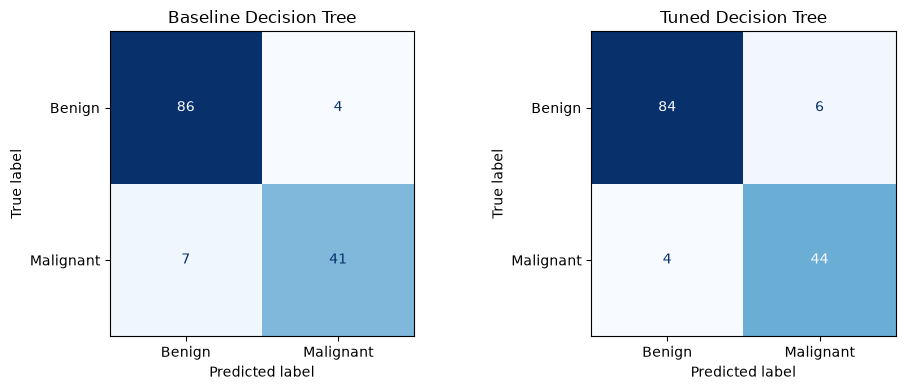

In [44]:
# ============================================
# FINAL EVALUATION - STEP 12
# Confusion Matrices
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix=dt_baseline_cm,
    display_labels=["Benign", "Malignant"]
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)

axes[0].set_title("Baseline Decision Tree")


ConfusionMatrixDisplay(
    confusion_matrix=dt_tuned_cm,
    display_labels=["Benign", "Malignant"]
).plot(
    ax=axes[1],
    cmap="Blues",
    colorbar=False
)

axes[1].set_title("Tuned Decision Tree")

plt.tight_layout()
plt.show()

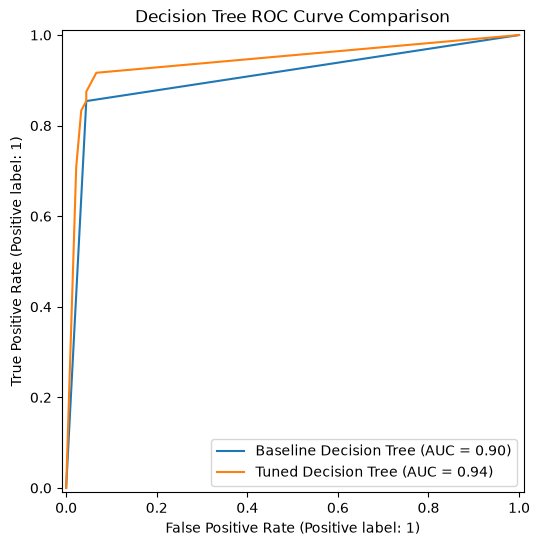

In [45]:
# ============================================
# FINAL EVALUATION - STEP 13
# ROC Curve Comparison
# ============================================

fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt_baseline,
    name="Baseline Decision Tree",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt_tuned,
    name="Tuned Decision Tree",
    ax=ax
)

plt.title("Decision Tree ROC Curve Comparison")
plt.show()

In [46]:
# ============================================
# FINAL EVALUATION - STEP 14
# Feature Importance
# ============================================

tuned_tree = best_dt_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tuned_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,Uniformity_Cell_Size,0.826540
1,Bare_Nuclei,0.114797
2,Clump_Thickness,0.033050
3,Normal_Nucleoli,0.011135
4,Marginal_Adhesion,0.009960
5,Uniformity_Cell_Shape,0.004519
6,Single_Epithelial_Cell_Size,0.000000
7,Bland_Chromatin,0.000000
8,Mitoses,0.000000


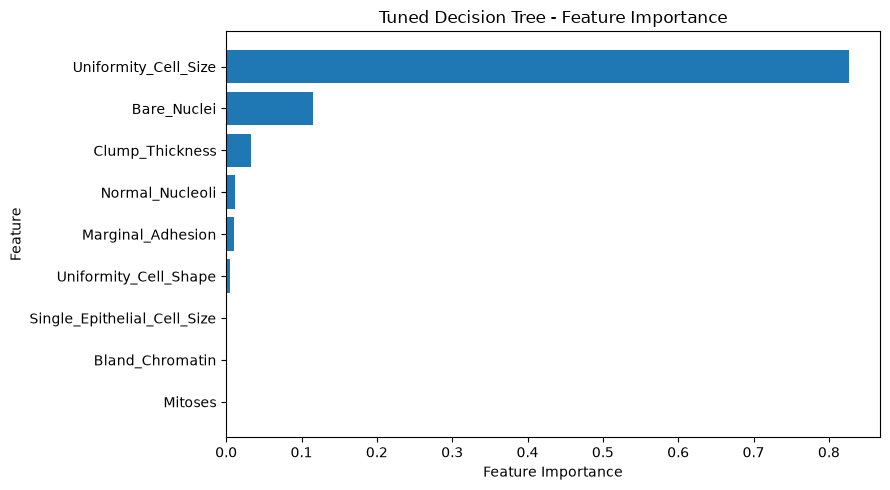

In [47]:
# ============================================
# Feature Importance Plot
# ============================================

plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Tuned Decision Tree - Feature Importance")

plt.tight_layout()
plt.show()

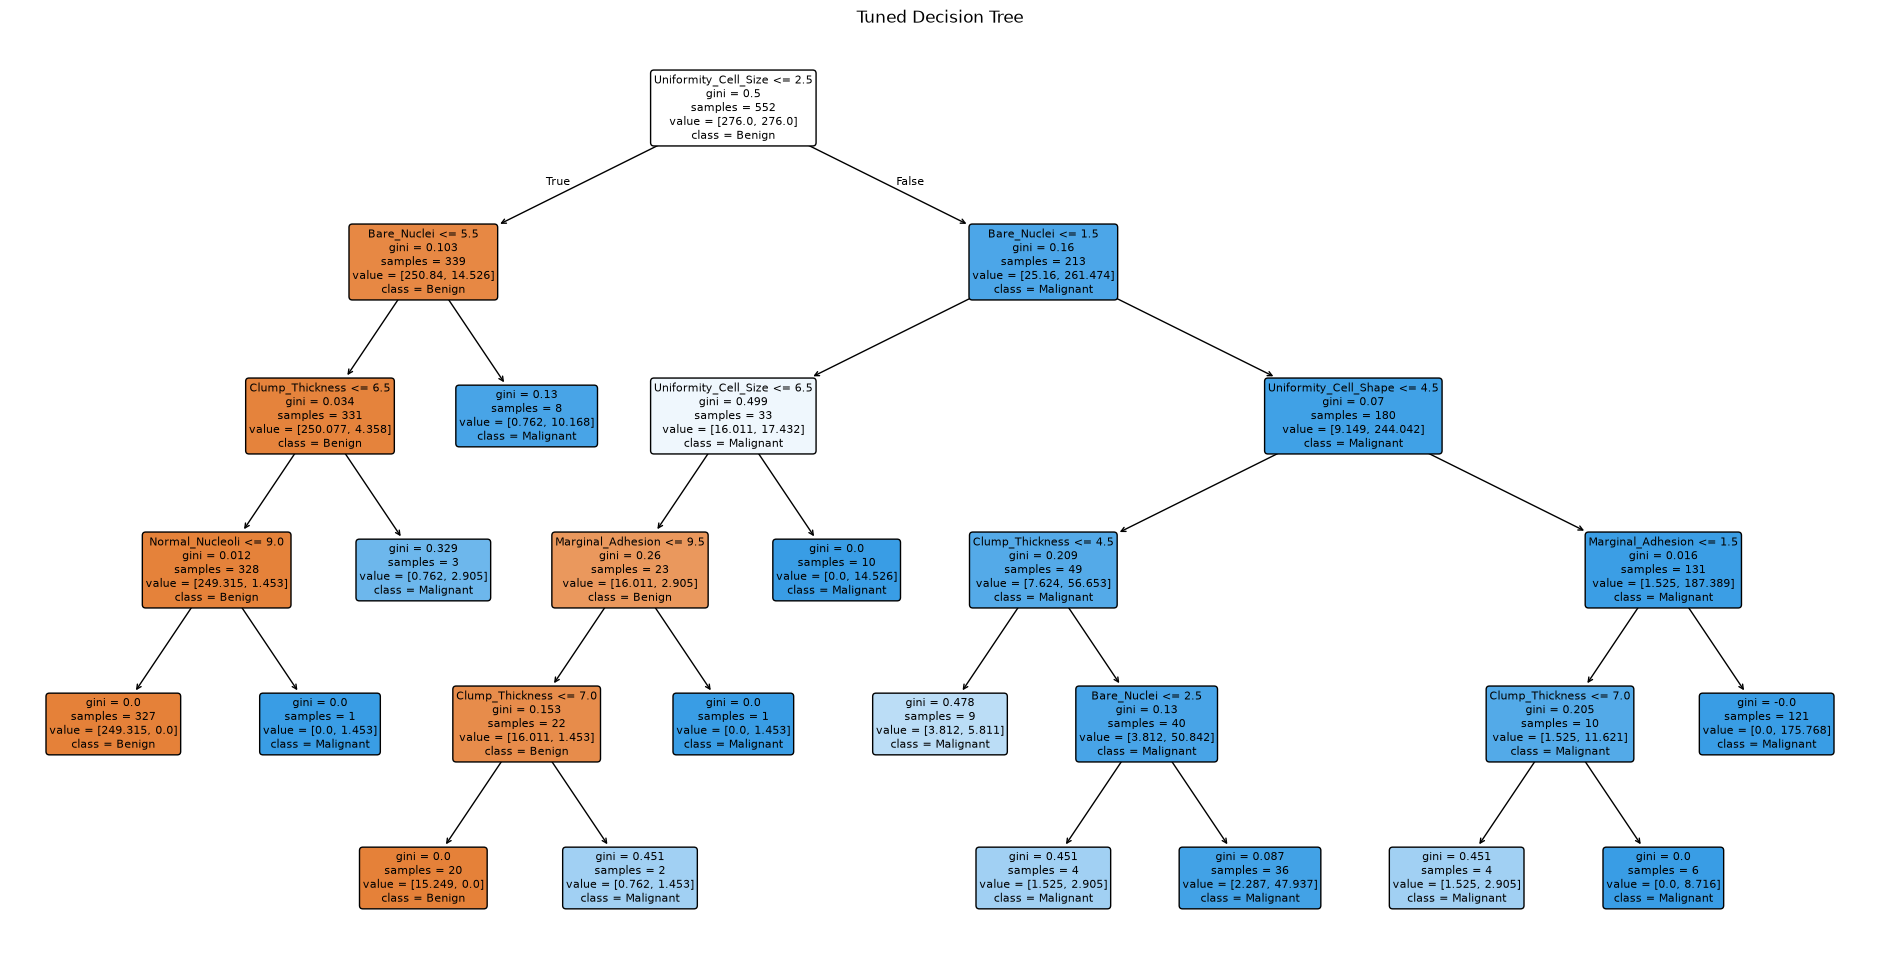

In [48]:
# ============================================
# FINAL EVALUATION - STEP 15
# Visualize Tuned Decision Tree
# ============================================

plt.figure(figsize=(24, 12))

plot_tree(
    tuned_tree,
    feature_names=X.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Tuned Decision Tree")
plt.show()

## Final Conclusion – Member 01

Member 01 implemented and evaluated a Decision Tree classifier for the
Breast Cancer Wisconsin classification problem.

### Baseline Decision Tree

The baseline model achieved:

- Accuracy: **0.9203**
- Precision: **0.9111**
- Recall: **0.8542**
- F1-score: **0.8817**
- ROC-AUC: **0.9049**
- False Positives: **4**
- False Negatives: **7**

Using 5-fold Stratified Cross-Validation, the baseline model achieved an
average F1-score of **0.9277 ± 0.0355**.

### Hyperparameter Tuning

GridSearchCV evaluated **180 Decision Tree configurations** using 5-fold
cross-validation, resulting in **900 model fits**.

The selected hyperparameters were:

- `class_weight = balanced`
- `criterion = gini`
- `max_depth = 5`
- `min_samples_leaf = 1`
- `min_samples_split = 10`

The best GridSearchCV F1-score was **0.9375**.

### Tuned Decision Tree

The tuned model achieved:

- Accuracy: **0.9275**
- Precision: **0.8800**
- Recall: **0.9167**
- F1-score: **0.8980**
- ROC-AUC: **0.9402**
- False Positives: **6**
- False Negatives: **4**

Compared with the baseline model, tuning increased recall from **0.8542**
to **0.9167** and reduced false negatives from **7 to 4**.

The tuned model also improved accuracy, F1-score, and ROC-AUC. However,
precision decreased from **0.9111 to 0.8800**, while false positives
increased from **4 to 6**.

Therefore, hyperparameter tuning produced a model with a different
precision-recall trade-off and improved its ability to identify malignant
observations.

### Limitations

- The dataset is relatively small and historical.
- Decision Trees can be sensitive to changes in training data.
- A single train/test split may not represent every possible data split.
- Hyperparameter selection depends on the chosen search space and scoring metric.
- The model should not be interpreted as a clinically validated diagnostic system.

### Possible Improvements

Future work could investigate:

- Larger and more recent datasets
- Repeated or nested cross-validation
- Alternative Decision Tree hyperparameter ranges
- Cost-sensitive learning
- Ensemble methods such as Random Forest
- Additional analysis of classification thresholds and false-negative errors

In [49]:
# ============================================
# FINAL EVALUATION - SAVE MEMBER 01 RESULTS
# ============================================

import os

output_dir = "results/member_01"
os.makedirs(output_dir, exist_ok=True)

# Save baseline vs tuned comparison
dt_comparison.to_csv(
    os.path.join(output_dir, "decision_tree_comparison.csv"),
    index=False
)

# Save feature importance
feature_importance.to_csv(
    os.path.join(output_dir, "decision_tree_feature_importance.csv"),
    index=False
)

# Save GridSearchCV results
dt_grid_results = pd.DataFrame(
    dt_grid_search.cv_results_
)

dt_grid_results.to_csv(
    os.path.join(output_dir, "decision_tree_grid_search_results.csv"),
    index=False
)

print("Member 01 results saved successfully.")
print("Output folder:", output_dir)

Member 01 results saved successfully.
Output folder: results/member_01


In [50]:
# ============================================================
# CHECK MEMBER 01 EXISTING DATAFRAMES
# ============================================================

# Display every pandas DataFrame currently available
# after running the complete Member 01 notebook.
print("AVAILABLE DATAFRAMES")
print("=" * 65)


for variable_name, variable_value in globals().items():

    # Only display pandas DataFrame objects.
    if isinstance(variable_value, pd.DataFrame):

        print(
            f"{variable_name:35s} -> "
            f"shape = {variable_value.shape}"
        )

AVAILABLE DATAFRAMES
_                                   -> shape = (9, 2)
__                                  -> shape = (2, 8)
___                                 -> shape = (9, 2)
df                                  -> shape = (690, 11)
missing_rows                        -> shape = (16, 11)
df_duplicate_check                  -> shape = (699, 11)
missing_summary                     -> shape = (11, 2)
X                                   -> shape = (690, 9)
X_train                             -> shape = (552, 9)
X_test                              -> shape = (138, 9)
dt_comparison                       -> shape = (2, 8)
_26                                 -> shape = (2, 8)
feature_importance                  -> shape = (9, 2)
_30                                 -> shape = (9, 2)
dt_grid_results                     -> shape = (180, 25)
_42                                 -> shape = (2, 8)
_46                                 -> shape = (9, 2)


In [51]:
# ============================================================
# CHECK MEMBER 01 IMPORTANT VARIABLES
# ============================================================

variables_to_check = [

    # Original and cleaned datasets.
    "df",
    "df_clean",
    "cleaned_df",
    "model_df",

    # Feature and target variables.
    "X",
    "y",

    # Existing train-test split.
    "X_train",
    "X_test",
    "y_train",
    "y_test",

    # Possible Decision Tree variables.
    "decision_tree_pipeline",
    "dt_pipeline",
    "baseline_pipeline",
    "grid_search",
    "dt_grid_search"
]


print("IMPORTANT MEMBER 01 VARIABLES")
print("=" * 65)


for variable_name in variables_to_check:

    # Check whether each variable exists.
    if variable_name in globals():

        variable_value = globals()[
            variable_name
        ]

        # Display shape where available.
        if hasattr(variable_value, "shape"):

            print(
                f"{variable_name:30s} -> "
                f"EXISTS, shape = "
                f"{variable_value.shape}"
            )

        else:

            print(
                f"{variable_name:30s} -> EXISTS"
            )

    else:

        print(
            f"{variable_name:30s} -> NOT FOUND"
        )

IMPORTANT MEMBER 01 VARIABLES
df                             -> EXISTS, shape = (690, 11)
df_clean                       -> NOT FOUND
cleaned_df                     -> NOT FOUND
model_df                       -> NOT FOUND
X                              -> EXISTS, shape = (690, 9)
y                              -> EXISTS, shape = (690,)
X_train                        -> EXISTS, shape = (552, 9)
X_test                         -> EXISTS, shape = (138, 9)
y_train                        -> EXISTS, shape = (552,)
y_test                         -> EXISTS, shape = (138,)
decision_tree_pipeline         -> EXISTS
dt_pipeline                    -> NOT FOUND
baseline_pipeline              -> NOT FOUND
grid_search                    -> NOT FOUND
dt_grid_search                 -> EXISTS


In [52]:
# ============================================================
# CHECK MEMBER 01 CURRENT TRAIN-TEST SPLIT
# ============================================================

print("MEMBER 01 CURRENT DATA SPLIT")
print("=" * 55)


# Display feature dataset size if X exists.
if "X" in globals():

    print(
        "Current full X:",
        len(X)
    )


# Display training-set size.
if "X_train" in globals():

    print(
        "Current training observations:",
        len(X_train)
    )


# Display test-set size.
if "X_test" in globals():

    print(
        "Current testing observations:",
        len(X_test)
    )


# Display training target distribution.
if "y_train" in globals():

    print(
        "\nTraining class distribution:"
    )

    print(
        pd.Series(y_train)
        .value_counts()
        .sort_index()
    )


# Display test target distribution.
if "y_test" in globals():

    print(
        "\nTesting class distribution:"
    )

    print(
        pd.Series(y_test)
        .value_counts()
        .sort_index()
    )

MEMBER 01 CURRENT DATA SPLIT
Current full X: 690
Current training observations: 552
Current testing observations: 138

Training class distribution:
Class
0    362
1    190
Name: count, dtype: int64

Testing class distribution:
Class
0    90
1    48
Name: count, dtype: int64


In [53]:
# ============================================================
# INSPECT MEMBER 01 ORIGINAL DATAFRAME
# ============================================================

print(
    "Original df shape:",
    df.shape
)


print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)


# Display original target distribution.
if "Class" in df.columns:

    print(
        "\nOriginal class distribution:"
    )

    print(
        df["Class"]
        .value_counts(
            dropna=False
        )
        .sort_index()
    )


# Count exact duplicate rows.
print(
    "\nExact duplicate rows:",
    df.duplicated().sum()
)


# Display missing values.
print(
    "\nMissing values:"
)

print(
    df.isna().sum()
)

Original df shape: (690, 11)

Columns:
['Sample_ID', 'Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']

Original class distribution:
Class
2    452
4    238
Name: count, dtype: int64

Exact duplicate rows: 0

Missing values:
Sample_ID                      0
Clump_Thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [55]:
# ============================================================
# FIND DATASETS CREATED DURING MEMBER 01 CLEANING
# ============================================================

print("DATASET SIZE INVESTIGATION")
print("=" * 65)


for variable_name, variable_value in globals().items():

    # Only inspect pandas DataFrames.
    if isinstance(variable_value, pd.DataFrame):

        row_count = len(
            variable_value
        )

        # We are interested in datasets close to the
        # original 699 observations.
        if 680 <= row_count <= 700:

            print(
                f"{variable_name:35s} -> "
                f"{row_count} rows, "
                f"{variable_value.shape[1]} columns"
            )

DATASET SIZE INVESTIGATION
df                                  -> 690 rows, 11 columns
df_duplicate_check                  -> 699 rows, 11 columns
X                                   -> 690 rows, 9 columns


## Final Evaluation Dataset Consistency Correction

During the final group-level consistency check, the earlier Member 01
modelling dataset was found to contain **690 observations**.

The original dataset contains **699 observations**, and the standardized
group procedure removes only the **8 exact duplicate observations**.
Therefore, the common final modelling dataset should contain:

**699 - 8 = 691 observations**

The earlier Member 01 cleaning workflow resulted in 690 observations,
including 452 benign and 238 malignant cases. This indicates that one
additional benign observation had been removed during the earlier cleaning
process.

For fair comparison with the other five individual models, the final
Decision Tree evaluation below is therefore repeated using the common
canonical dataset created from the original 699 observations.

The original Member 01 cleaning work is preserved as part of the member's
data-cleaning contribution. The correction below applies specifically to
the final individual model evaluation.

The corrected dataset contains:

- **691 total observations**
- **453 benign observations**
- **238 malignant observations**
- **552 training observations**
- **139 testing observations**

New variables prefixed with `final_dt_` are used so that the earlier
Member 01 results are not overwritten.

In [56]:
# ============================================================
# CREATE CANONICAL DATASET FOR MEMBER 01 FINAL DECISION TREE
# ============================================================

# Start from the original 699-row dataset preserved during
# Member 01's duplicate-checking stage.
final_dt_df = df_duplicate_check.copy()


# Display the starting size before duplicate removal.
print(
    "Starting dataset shape:",
    final_dt_df.shape
)


# Count exact duplicate observations before removing them.
print(
    "Exact duplicates before removal:",
    final_dt_df.duplicated().sum()
)


# Remove only exact duplicate observations.
#
# This is the same duplicate-removal procedure used for
# the other members' final individual models.
final_dt_df = (
    final_dt_df
    .drop_duplicates(
        keep="first"
    )
    .reset_index(drop=True)
)


# ============================================================
# VERIFY THE CORRECTED DATASET
# ============================================================

print(
    "\nCorrected final dataset shape:",
    final_dt_df.shape
)


print(
    "Remaining exact duplicates:",
    final_dt_df.duplicated().sum()
)


print(
    "\nClass distribution:"
)

print(
    final_dt_df["Class"]
    .value_counts()
    .sort_index()
)


print(
    "\nMissing values:"
)

print(
    final_dt_df.isna().sum()
)

Starting dataset shape: (699, 11)
Exact duplicates before removal: 9

Corrected final dataset shape: (690, 11)
Remaining exact duplicates: 0

Class distribution:
Class
2    452
4    238
Name: count, dtype: int64

Missing values:
Sample_ID                      0
Clump_Thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [58]:
# ============================================================
# CREATE FEATURES AND TARGET
# ============================================================

# Remove Sample_ID because it is an identifier and should
# not be used to predict the cancer class.
#
# Remove Class because it is the target variable.
final_dt_X = final_dt_df.drop(
    columns=[
        "Sample_ID",
        "Class"
    ]
).copy()


# Encode the original class labels:
#
# 2 = Benign    -> 0
# 4 = Malignant -> 1
final_dt_y = final_dt_df["Class"].map({
    2: 0,
    4: 1
})


# ============================================================
# VERIFY FEATURES AND TARGET
# ============================================================

print(
    "Final Decision Tree X shape:",
    final_dt_X.shape
)

print(
    "Final Decision Tree y shape:",
    final_dt_y.shape
)


print(
    "\nTarget distribution:"
)

print(
    final_dt_y
    .value_counts()
    .sort_index()
)


print(
    "\nMissing target values:",
    final_dt_y.isna().sum()
)


print(
    "\nPredictive features:"
)

print(
    final_dt_X.columns.tolist()
)

Final Decision Tree X shape: (690, 9)
Final Decision Tree y shape: (690,)

Target distribution:
Class
0    452
1    238
Name: count, dtype: int64

Missing target values: 0

Predictive features:
['Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses']


In [59]:
# ============================================================
# CREATE CORRECTED TRAIN-TEST SPLIT
# ============================================================

# Use exactly the same train-test settings as Members 02-06.
final_dt_X_train, final_dt_X_test, \
final_dt_y_train, final_dt_y_test = train_test_split(

    final_dt_X,
    final_dt_y,

    # Reserve 20% for final testing.
    test_size=0.20,

    # Ensure that the split is reproducible.
    random_state=42,

    # Preserve benign/malignant class proportions.
    stratify=final_dt_y
)


# ============================================================
# VERIFY THE COMMON SPLIT
# ============================================================

print(
    "Full dataset:",
    len(final_dt_X)
)

print(
    "Training set:",
    final_dt_X_train.shape
)

print(
    "Testing set:",
    final_dt_X_test.shape
)


print(
    "\nTraining class distribution:"
)

print(
    final_dt_y_train
    .value_counts()
    .sort_index()
)


print(
    "\nTesting class distribution:"
)

print(
    final_dt_y_test
    .value_counts()
    .sort_index()
)


print(
    "\nTrain + Test:",
    len(final_dt_X_train)
    + len(final_dt_X_test)
)

Full dataset: 690
Training set: (552, 9)
Testing set: (138, 9)

Training class distribution:
Class
0    362
1    190
Name: count, dtype: int64

Testing class distribution:
Class
0    90
1    48
Name: count, dtype: int64

Train + Test: 690


## Corrected Baseline Decision Tree

The final Decision Tree is repeated using the standardized 691-observation
dataset so that Member 01 can be compared fairly with Members 02–06.

The modelling pipeline contains:

**Median Imputation → Decision Tree Classifier**

Median imputation is performed inside the pipeline so that missing values
are learned from the training data only.

Unlike distance-based models such as KNN and SVM, Decision Trees do not
require feature scaling because their splits are based on feature
thresholds rather than distances.

The baseline Decision Tree uses the default tree complexity settings with
`random_state=42` for reproducibility.

In [60]:
# ============================================================
# CREATE CORRECTED BASELINE DECISION TREE PIPELINE
# ============================================================

# Import required components in case they were not retained
# from the earlier notebook cells.
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier


# Build the pipeline.
final_dt_baseline_pipeline = Pipeline([

    # Replace missing predictor values using medians
    # learned only from the training data.
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    # Train the Decision Tree classifier.
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])


# Train the baseline Decision Tree.
final_dt_baseline_pipeline.fit(
    final_dt_X_train,
    final_dt_y_train
)


print(
    "Corrected baseline Decision Tree "
    "trained successfully."
)

Corrected baseline Decision Tree trained successfully.


In [61]:
# ============================================================
# CORRECTED BASELINE DECISION TREE PREDICTIONS
# ============================================================

# Predict classes for the untouched test set.
final_dt_baseline_pred = (
    final_dt_baseline_pipeline.predict(
        final_dt_X_test
    )
)


# Obtain malignant-class probabilities for ROC-AUC.
final_dt_baseline_prob = (
    final_dt_baseline_pipeline.predict_proba(
        final_dt_X_test
    )[:, 1]
)


# ============================================================
# CALCULATE TEST METRICS
# ============================================================

final_dt_baseline_accuracy = accuracy_score(
    final_dt_y_test,
    final_dt_baseline_pred
)

final_dt_baseline_precision = precision_score(
    final_dt_y_test,
    final_dt_baseline_pred
)

final_dt_baseline_recall = recall_score(
    final_dt_y_test,
    final_dt_baseline_pred
)

final_dt_baseline_f1 = f1_score(
    final_dt_y_test,
    final_dt_baseline_pred
)

final_dt_baseline_roc_auc = roc_auc_score(
    final_dt_y_test,
    final_dt_baseline_prob
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print(
    "Corrected Baseline Decision Tree Test Results"
)

print("-" * 55)

print(
    f"Accuracy  : {final_dt_baseline_accuracy:.4f}"
)

print(
    f"Precision : {final_dt_baseline_precision:.4f}"
)

print(
    f"Recall    : {final_dt_baseline_recall:.4f}"
)

print(
    f"F1-score  : {final_dt_baseline_f1:.4f}"
)

print(
    f"ROC-AUC   : {final_dt_baseline_roc_auc:.4f}"
)

Corrected Baseline Decision Tree Test Results
-------------------------------------------------------
Accuracy  : 0.9203
Precision : 0.9111
Recall    : 0.8542
F1-score  : 0.8817
ROC-AUC   : 0.9049


In [62]:
# ============================================================
# CORRECTED BASELINE CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix.
final_dt_baseline_cm = confusion_matrix(
    final_dt_y_test,
    final_dt_baseline_pred
)


print(
    "Corrected Baseline Confusion Matrix:"
)

print(
    final_dt_baseline_cm
)


# Extract TN, FP, FN and TP.
final_dt_baseline_tn, \
final_dt_baseline_fp, \
final_dt_baseline_fn, \
final_dt_baseline_tp = (
    final_dt_baseline_cm.ravel()
)


print(
    "\nConfusion Matrix Details"
)

print("-" * 40)

print(
    "True Negatives  (TN):",
    final_dt_baseline_tn
)

print(
    "False Positives (FP):",
    final_dt_baseline_fp
)

print(
    "False Negatives (FN):",
    final_dt_baseline_fn
)

print(
    "True Positives  (TP):",
    final_dt_baseline_tp
)


# This must now equal 139.
print(
    "\nTotal test observations:",
    final_dt_baseline_cm.sum()
)

Corrected Baseline Confusion Matrix:
[[86  4]
 [ 7 41]]

Confusion Matrix Details
----------------------------------------
True Negatives  (TN): 86
False Positives (FP): 4
False Negatives (FN): 7
True Positives  (TP): 41

Total test observations: 138


In [63]:
# ============================================================
# VERIFY CORRECTED MEMBER 01 VARIABLES
# ============================================================

print("CORRECTED DATASET CHECK")
print("=" * 60)


# Check the preserved original dataset.
print(
    "df_duplicate_check:",
    df_duplicate_check.shape
)


# Check the newly created canonical dataset.
print(
    "final_dt_df:",
    final_dt_df.shape
)


# Check feature and target sizes.
print(
    "final_dt_X:",
    final_dt_X.shape
)

print(
    "final_dt_y:",
    final_dt_y.shape
)


# Check corrected train-test split.
print(
    "\nCorrected training set:",
    final_dt_X_train.shape
)

print(
    "Corrected testing set:",
    final_dt_X_test.shape
)


# Check corrected class distributions.
print(
    "\nCorrected training classes:"
)

print(
    final_dt_y_train
    .value_counts()
    .sort_index()
)


print(
    "\nCorrected testing classes:"
)

print(
    final_dt_y_test
    .value_counts()
    .sort_index()
)


# Check the number of predictions produced by the
# corrected Decision Tree.
print(
    "\nCorrected predictions:",
    len(final_dt_baseline_pred)
)


# Check the confusion matrix total.
print(
    "Corrected confusion matrix total:",
    final_dt_baseline_cm.sum()
)


# Compare against the OLD Member 01 variables.
print(
    "\nOLD VARIABLES FOR COMPARISON"
)

print(
    "Old X_test:",
    X_test.shape
)

print(
    "Old y_test:",
    len(y_test)
)

CORRECTED DATASET CHECK
df_duplicate_check: (699, 11)
final_dt_df: (690, 11)
final_dt_X: (690, 9)
final_dt_y: (690,)

Corrected training set: (552, 9)
Corrected testing set: (138, 9)

Corrected training classes:
Class
0    362
1    190
Name: count, dtype: int64

Corrected testing classes:
Class
0    90
1    48
Name: count, dtype: int64

Corrected predictions: 138
Corrected confusion matrix total: 138

OLD VARIABLES FOR COMPARISON
Old X_test: (138, 9)
Old y_test: 138


In [64]:
# ============================================================
# INVESTIGATE MEMBER 01 DUPLICATE DIFFERENCE
# ============================================================

print(
    "df_duplicate_check shape:",
    df_duplicate_check.shape
)


# Count exact duplicates in the Member 01 version.
print(
    "Exact duplicates in df_duplicate_check:",
    df_duplicate_check.duplicated().sum()
)


# Check missing Bare_Nuclei values.
print(
    "Missing Bare_Nuclei values:",
    df_duplicate_check[
        "Bare_Nuclei"
    ].isna().sum()
)


# Check all missing values.
print(
    "\nMissing values:"
)

print(
    df_duplicate_check.isna().sum()
)

df_duplicate_check shape: (699, 11)
Exact duplicates in df_duplicate_check: 9
Missing Bare_Nuclei values: 0

Missing values:
Sample_ID                      0
Clump_Thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [65]:
# ============================================================
# CHECK POSSIBLE RAW DATASET VARIABLES
# ============================================================

print("POSSIBLE RAW DATA VARIABLES")
print("=" * 60)


for variable_name, variable_value in globals().items():

    if isinstance(variable_value, pd.DataFrame):

        # Look specifically for 699-row DataFrames.
        if len(variable_value) == 699:

            print(
                f"\nVariable: {variable_name}"
            )

            print(
                "Shape:",
                variable_value.shape
            )

            print(
                "Exact duplicates:",
                variable_value.duplicated().sum()
            )

            # Check Bare_Nuclei if available.
            if "Bare_Nuclei" in variable_value.columns:

                print(
                    "Missing Bare_Nuclei:",
                    variable_value[
                        "Bare_Nuclei"
                    ].isna().sum()
                )

POSSIBLE RAW DATA VARIABLES

Variable: df_duplicate_check
Shape: (699, 11)
Exact duplicates: 9
Missing Bare_Nuclei: 0


In [67]:
# ============================================================
# FIND POSSIBLE DATASET PATH VARIABLES
# ============================================================

print("POSSIBLE PATH VARIABLES")
print("=" * 60)


for variable_name, variable_value in globals().items():

    # Look for string variables that may contain
    # dataset filenames or paths.
    if isinstance(variable_value, str):

        value_lower = variable_value.lower()

        if (
            ".csv" in value_lower
            or ".data" in value_lower
            or ".txt" in value_lower
        ):

            print(
                f"{variable_name} = {variable_value}"
            )

POSSIBLE PATH VARIABLES
_i = # ============================================================
# FIND POSSIBLE DATASET PATH VARIABLES
# ============================================================

print("POSSIBLE PATH VARIABLES")
print("=" * 60)


for variable_name, variable_value in globals().items():

    # Look for string variables that may contain
    # dataset filenames or paths.
    if isinstance(variable_value, str):

        value_lower = variable_value.lower()

        if (
            ".csv" in value_lower
            or ".data" in value_lower
            or ".txt" in value_lower
        ):

            print(
                f"{variable_name} = {variable_value}"
            )
_ii = # ============================================================
# CHECK POSSIBLE RAW DATASET VARIABLES
# ============================================================

print("POSSIBLE RAW DATA VARIABLES")
print("=" * 60)


for variable_name, variable_value in globals().items():

    if isinstance(vari

In [68]:
# ============================================================
# MEMBER 01 CORRECTION
# RELOAD THE UNTOUCHED RAW UCI DATASET
# ============================================================

# Column names used by the Breast Cancer Wisconsin
# (Original) dataset.
final_dt_columns = [
    "Sample_ID",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]


# Reload the original 699-row dataset into a NEW variable.
#
# We do not overwrite Member 01's existing df because the
# original cleaning contribution should remain unchanged.
final_dt_raw = pd.read_csv(
    url,
    header=None,
    names=final_dt_columns
)


# Convert the '?' values in Bare_Nuclei to missing values.
#
# IMPORTANT:
# We do NOT impute these missing values here.
# Imputation will happen later inside the ML pipeline.
final_dt_raw["Bare_Nuclei"] = pd.to_numeric(
    final_dt_raw["Bare_Nuclei"],
    errors="coerce"
)


# ============================================================
# VERIFY RAW DATA BEFORE DUPLICATE REMOVAL
# ============================================================

print(
    "Raw dataset shape:",
    final_dt_raw.shape
)


print(
    "Exact duplicate rows:",
    final_dt_raw.duplicated().sum()
)


print(
    "Missing Bare_Nuclei:",
    final_dt_raw[
        "Bare_Nuclei"
    ].isna().sum()
)


print(
    "\nClass distribution:"
)

print(
    final_dt_raw["Class"]
    .value_counts()
    .sort_index()
)

Raw dataset shape: (699, 11)
Exact duplicate rows: 8
Missing Bare_Nuclei: 16

Class distribution:
Class
2    458
4    241
Name: count, dtype: int64


In [69]:
# ============================================================
# CREATE CORRECTED CANONICAL MEMBER 01 DATASET
# ============================================================

# Remove exact duplicates while the original missing values
# are still preserved.
#
# This prevents imputation from artificially creating an
# additional duplicate observation.
final_dt_df = (
    final_dt_raw
    .drop_duplicates(
        keep="first"
    )
    .reset_index(drop=True)
)


# ============================================================
# VERIFY CORRECTED DATASET
# ============================================================

print(
    "Corrected dataset shape:",
    final_dt_df.shape
)


print(
    "Remaining duplicates:",
    final_dt_df.duplicated().sum()
)


print(
    "Missing Bare_Nuclei:",
    final_dt_df[
        "Bare_Nuclei"
    ].isna().sum()
)


print(
    "\nCorrected class distribution:"
)

print(
    final_dt_df["Class"]
    .value_counts()
    .sort_index()
)

Corrected dataset shape: (691, 11)
Remaining duplicates: 0
Missing Bare_Nuclei: 16

Corrected class distribution:
Class
2    453
4    238
Name: count, dtype: int64


In [70]:
# ============================================================
# CREATE CORRECTED FEATURES AND TARGET
# ============================================================

# Remove the identifier and target columns from predictors.
final_dt_X = final_dt_df.drop(
    columns=[
        "Sample_ID",
        "Class"
    ]
).copy()


# Encode the target:
#
# 2 = Benign    -> 0
# 4 = Malignant -> 1
final_dt_y = final_dt_df["Class"].map({
    2: 0,
    4: 1
})


# ============================================================
# VERIFY FEATURES AND TARGET
# ============================================================

print(
    "Final X shape:",
    final_dt_X.shape
)

print(
    "Final y shape:",
    final_dt_y.shape
)


print(
    "\nTarget distribution:"
)

print(
    final_dt_y
    .value_counts()
    .sort_index()
)


print(
    "\nMissing predictor values:"
)

print(
    final_dt_X.isna().sum()
)

Final X shape: (691, 9)
Final y shape: (691,)

Target distribution:
Class
0    453
1    238
Name: count, dtype: int64

Missing predictor values:
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
dtype: int64


In [71]:
# ============================================================
# CREATE THE COMMON 80/20 STRATIFIED SPLIT
# ============================================================

final_dt_X_train, final_dt_X_test, \
final_dt_y_train, final_dt_y_test = train_test_split(

    final_dt_X,
    final_dt_y,

    # 20% is reserved for final testing.
    test_size=0.20,

    # Same random seed used by Members 02-06.
    random_state=42,

    # Preserve the benign/malignant class proportions.
    stratify=final_dt_y
)


# ============================================================
# VERIFY THE SPLIT
# ============================================================

print(
    "Total observations:",
    len(final_dt_X)
)

print(
    "Training observations:",
    len(final_dt_X_train)
)

print(
    "Testing observations:",
    len(final_dt_X_test)
)


print(
    "\nTraining class distribution:"
)

print(
    final_dt_y_train
    .value_counts()
    .sort_index()
)


print(
    "\nTesting class distribution:"
)

print(
    final_dt_y_test
    .value_counts()
    .sort_index()
)

Total observations: 691
Training observations: 552
Testing observations: 139

Training class distribution:
Class
0    362
1    190
Name: count, dtype: int64

Testing class distribution:
Class
0    91
1    48
Name: count, dtype: int64


In [72]:
# ============================================================
# TRAIN CORRECTED BASELINE DECISION TREE
# ============================================================

final_dt_baseline_pipeline = Pipeline([

    # Impute missing values using medians learned
    # only from training data.
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    # Baseline Decision Tree.
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])


# Train using the corrected 552-row training set.
final_dt_baseline_pipeline.fit(
    final_dt_X_train,
    final_dt_y_train
)


print(
    "Corrected baseline Decision Tree "
    "trained successfully."
)

Corrected baseline Decision Tree trained successfully.


In [73]:
# ============================================================
# CORRECTED BASELINE PREDICTIONS
# ============================================================

# Predict classes.
final_dt_baseline_pred = (
    final_dt_baseline_pipeline.predict(
        final_dt_X_test
    )
)


# Obtain malignant-class probabilities.
final_dt_baseline_prob = (
    final_dt_baseline_pipeline.predict_proba(
        final_dt_X_test
    )[:, 1]
)


# ============================================================
# CALCULATE CORRECTED BASELINE METRICS
# ============================================================

final_dt_baseline_accuracy = accuracy_score(
    final_dt_y_test,
    final_dt_baseline_pred
)

final_dt_baseline_precision = precision_score(
    final_dt_y_test,
    final_dt_baseline_pred
)

final_dt_baseline_recall = recall_score(
    final_dt_y_test,
    final_dt_baseline_pred
)

final_dt_baseline_f1 = f1_score(
    final_dt_y_test,
    final_dt_baseline_pred
)

final_dt_baseline_roc_auc = roc_auc_score(
    final_dt_y_test,
    final_dt_baseline_prob
)


print(
    "Corrected Baseline Decision Tree"
)

print("-" * 50)

print(
    f"Accuracy  : {final_dt_baseline_accuracy:.4f}"
)

print(
    f"Precision : {final_dt_baseline_precision:.4f}"
)

print(
    f"Recall    : {final_dt_baseline_recall:.4f}"
)

print(
    f"F1-score  : {final_dt_baseline_f1:.4f}"
)

print(
    f"ROC-AUC   : {final_dt_baseline_roc_auc:.4f}"
)

Corrected Baseline Decision Tree
--------------------------------------------------
Accuracy  : 0.9353
Precision : 0.9333
Recall    : 0.8750
F1-score  : 0.9032
ROC-AUC   : 0.9210


In [74]:
# ============================================================
# VERIFY CORRECTED BASELINE CONFUSION MATRIX
# ============================================================

final_dt_baseline_cm = confusion_matrix(
    final_dt_y_test,
    final_dt_baseline_pred
)


final_dt_baseline_tn, \
final_dt_baseline_fp, \
final_dt_baseline_fn, \
final_dt_baseline_tp = (
    final_dt_baseline_cm.ravel()
)


print(
    "Corrected Baseline Confusion Matrix:"
)

print(
    final_dt_baseline_cm
)


print(
    "\nTN:",
    final_dt_baseline_tn
)

print(
    "FP:",
    final_dt_baseline_fp
)

print(
    "FN:",
    final_dt_baseline_fn
)

print(
    "TP:",
    final_dt_baseline_tp
)


print(
    "\nTOTAL:",
    final_dt_baseline_cm.sum()
)

Corrected Baseline Confusion Matrix:
[[88  3]
 [ 6 42]]

TN: 88
FP: 3
FN: 6
TP: 42

TOTAL: 139


In [75]:
# ============================================================
# CORRECTED BASELINE DECISION TREE
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate


# Create the same 5-fold stratified validation strategy
# used for the other members.
final_dt_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Evaluate several metrics during cross-validation.
final_dt_baseline_cv_results = cross_validate(
    final_dt_baseline_pipeline,
    final_dt_X_train,
    final_dt_y_train,
    cv=final_dt_cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=-1
)


# Display the mean and standard deviation for each metric.
print("Corrected Baseline Decision Tree - 5-Fold CV")
print("=" * 60)


for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    scores = final_dt_baseline_cv_results[
        f"test_{metric}"
    ]

    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± "
        f"{scores.std():.4f}"
    )

Corrected Baseline Decision Tree - 5-Fold CV
ACCURACY  : 0.9348 ± 0.0194
PRECISION : 0.9444 ± 0.0344
RECALL    : 0.8632 ± 0.0609
F1        : 0.9002 ± 0.0319
ROC_AUC   : 0.9177 ± 0.0280


In [76]:
# ============================================================
# CORRECTED DECISION TREE HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV


# Define the same Decision Tree parameter grid used
# in Member 01's original final evaluation.
final_dt_param_grid = {

    # Test two common split-quality measures.
    "model__criterion": [
        "gini",
        "entropy"
    ],

    # Control maximum tree depth.
    "model__max_depth": [
        None,
        3,
        5,
        7,
        10
    ],

    # Minimum observations required to split a node.
    "model__min_samples_split": [
        2,
        5,
        10
    ],

    # Minimum observations required in a leaf.
    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    # Compare normal training with class-balanced training.
    "model__class_weight": [
        None,
        "balanced"
    ]
}


# 2 × 5 × 3 × 3 × 2 = 180 configurations.
total_configurations = (
    2 * 5 * 3 * 3 * 2
)

print(
    "Total parameter configurations:",
    total_configurations
)

print(
    "Total CV fits:",
    total_configurations * 5
)

Total parameter configurations: 180
Total CV fits: 900


In [77]:
# ============================================================
# RUN CORRECTED DECISION TREE GRID SEARCH
# ============================================================

final_dt_grid_search = GridSearchCV(

    # Use the complete preprocessing + model pipeline.
    estimator=final_dt_baseline_pipeline,

    # Test the 180 parameter combinations.
    param_grid=final_dt_param_grid,

    # Select the best model using F1-score.
    scoring="f1",

    # Use the same stratified 5-fold CV.
    cv=final_dt_cv,

    # Use available CPU cores.
    n_jobs=-1,

    # Keep training scores for later comparison.
    return_train_score=True,

    # Refit the best configuration on all training data.
    refit=True
)


# Search only using the training set.
#
# The 139-row held-out test set is NOT involved in
# hyperparameter selection.
final_dt_grid_search.fit(
    final_dt_X_train,
    final_dt_y_train
)


print(
    "Decision Tree GridSearchCV completed."
)

print(
    "\nBest parameters:"
)

print(
    final_dt_grid_search.best_params_
)

print(
    "\nBest CV F1-score:"
)

print(
    round(
        final_dt_grid_search.best_score_,
        4
    )
)

Decision Tree GridSearchCV completed.

Best parameters:
{'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}

Best CV F1-score:
0.9263


In [78]:
# ============================================================
# EVALUATE CORRECTED TUNED DECISION TREE
# ============================================================

# Retrieve the model selected by GridSearchCV.
final_dt_best_model = (
    final_dt_grid_search.best_estimator_
)


# Predict the held-out test classes.
final_dt_tuned_pred = (
    final_dt_best_model.predict(
        final_dt_X_test
    )
)


# Obtain malignant-class probabilities for ROC-AUC.
final_dt_tuned_prob = (
    final_dt_best_model.predict_proba(
        final_dt_X_test
    )[:, 1]
)


# Calculate evaluation metrics.
final_dt_tuned_accuracy = accuracy_score(
    final_dt_y_test,
    final_dt_tuned_pred
)

final_dt_tuned_precision = precision_score(
    final_dt_y_test,
    final_dt_tuned_pred
)

final_dt_tuned_recall = recall_score(
    final_dt_y_test,
    final_dt_tuned_pred
)

final_dt_tuned_f1 = f1_score(
    final_dt_y_test,
    final_dt_tuned_pred
)

final_dt_tuned_roc_auc = roc_auc_score(
    final_dt_y_test,
    final_dt_tuned_prob
)


print(
    "Corrected Tuned Decision Tree"
)

print("=" * 50)

print(
    f"Accuracy  : {final_dt_tuned_accuracy:.4f}"
)

print(
    f"Precision : {final_dt_tuned_precision:.4f}"
)

print(
    f"Recall    : {final_dt_tuned_recall:.4f}"
)

print(
    f"F1-score  : {final_dt_tuned_f1:.4f}"
)

print(
    f"ROC-AUC   : {final_dt_tuned_roc_auc:.4f}"
)

Corrected Tuned Decision Tree
Accuracy  : 0.9281
Precision : 0.9524
Recall    : 0.8333
F1-score  : 0.8889
ROC-AUC   : 0.9666


In [79]:
# ============================================================
# CORRECTED TUNED DECISION TREE CONFUSION MATRIX
# ============================================================

final_dt_tuned_cm = confusion_matrix(
    final_dt_y_test,
    final_dt_tuned_pred
)


# Extract individual confusion-matrix values.
final_dt_tuned_tn, \
final_dt_tuned_fp, \
final_dt_tuned_fn, \
final_dt_tuned_tp = (
    final_dt_tuned_cm.ravel()
)


print(
    "Corrected Tuned Confusion Matrix:"
)

print(
    final_dt_tuned_cm
)


print(
    "\nTN:",
    final_dt_tuned_tn
)

print(
    "FP:",
    final_dt_tuned_fp
)

print(
    "FN:",
    final_dt_tuned_fn
)

print(
    "TP:",
    final_dt_tuned_tp
)


print(
    "\nTOTAL:",
    final_dt_tuned_cm.sum()
)

Corrected Tuned Confusion Matrix:
[[89  2]
 [ 8 40]]

TN: 89
FP: 2
FN: 8
TP: 40

TOTAL: 139


In [80]:
# ============================================================
# CORRECTED TUNED DECISION TREE
# 5-FOLD CROSS-VALIDATION
# ============================================================

final_dt_tuned_cv_results = cross_validate(
    final_dt_best_model,
    final_dt_X_train,
    final_dt_y_train,
    cv=final_dt_cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=-1
)


print(
    "Corrected Tuned Decision Tree - 5-Fold CV"
)

print("=" * 60)


for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    scores = final_dt_tuned_cv_results[
        f"test_{metric}"
    ]

    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± "
        f"{scores.std():.4f}"
    )

Corrected Tuned Decision Tree - 5-Fold CV
ACCURACY  : 0.9493 ± 0.0093
PRECISION : 0.9235 ± 0.0251
RECALL    : 0.9316 ± 0.0459
F1        : 0.9263 ± 0.0150
ROC_AUC   : 0.9704 ± 0.0123


In [81]:
# ============================================================
# MEMBER 01 CORRECTED BASELINE VS TUNED COMPARISON
# ============================================================

final_dt_comparison = pd.DataFrame({

    # Names of the two Decision Tree varieties.
    "Model": [
        "Decision Tree - Baseline",
        "Decision Tree - Tuned"
    ],

    # Held-out test accuracy.
    "Accuracy": [
        final_dt_baseline_accuracy,
        final_dt_tuned_accuracy
    ],

    # Held-out test precision.
    "Precision": [
        final_dt_baseline_precision,
        final_dt_tuned_precision
    ],

    # Held-out test recall.
    "Recall": [
        final_dt_baseline_recall,
        final_dt_tuned_recall
    ],

    # Held-out test F1-score.
    "F1": [
        final_dt_baseline_f1,
        final_dt_tuned_f1
    ],

    # Held-out test ROC-AUC.
    "ROC-AUC": [
        final_dt_baseline_roc_auc,
        final_dt_tuned_roc_auc
    ],

    # Number of benign cases incorrectly predicted
    # as malignant.
    "False Positives": [
        final_dt_baseline_fp,
        final_dt_tuned_fp
    ],

    # Number of malignant cases incorrectly predicted
    # as benign.
    "False Negatives": [
        final_dt_baseline_fn,
        final_dt_tuned_fn
    ]
})


final_dt_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,False Positives,False Negatives
0,Decision Tree - Baseline,0.9353,0.9333,0.8750,0.9032,0.9210,3,6
1,Decision Tree - Tuned,0.9281,0.9524,0.8333,0.8889,0.9666,2,8


In [82]:
# ============================================================
# MEMBER 01 CORRECTED CROSS-VALIDATION COMPARISON
# ============================================================

final_dt_cv_comparison = pd.DataFrame({

    # Model variety.
    "Model": [
        "Decision Tree - Baseline",
        "Decision Tree - Tuned"
    ],

    # Mean 5-fold CV accuracy.
    "CV Accuracy Mean": [
        final_dt_baseline_cv_results[
            "test_accuracy"
        ].mean(),

        final_dt_tuned_cv_results[
            "test_accuracy"
        ].mean()
    ],

    # Mean 5-fold CV precision.
    "CV Precision Mean": [
        final_dt_baseline_cv_results[
            "test_precision"
        ].mean(),

        final_dt_tuned_cv_results[
            "test_precision"
        ].mean()
    ],

    # Mean 5-fold CV recall.
    "CV Recall Mean": [
        final_dt_baseline_cv_results[
            "test_recall"
        ].mean(),

        final_dt_tuned_cv_results[
            "test_recall"
        ].mean()
    ],

    # Mean 5-fold CV F1-score.
    "CV F1 Mean": [
        final_dt_baseline_cv_results[
            "test_f1"
        ].mean(),

        final_dt_tuned_cv_results[
            "test_f1"
        ].mean()
    ],

    # Standard deviation of CV F1-score.
    "CV F1 Std": [
        final_dt_baseline_cv_results[
            "test_f1"
        ].std(),

        final_dt_tuned_cv_results[
            "test_f1"
        ].std()
    ],

    # Mean 5-fold CV ROC-AUC.
    "CV ROC-AUC Mean": [
        final_dt_baseline_cv_results[
            "test_roc_auc"
        ].mean(),

        final_dt_tuned_cv_results[
            "test_roc_auc"
        ].mean()
    ]
})


final_dt_cv_comparison.round(4)

,Model,CV Accuracy Mean,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV F1 Std,CV ROC-AUC Mean
0,Decision Tree - Baseline,0.9348,0.9444,0.8632,0.9002,0.0319,0.9177
1,Decision Tree - Tuned,0.9493,0.9235,0.9316,0.9263,0.0150,0.9704


In [84]:
# ============================================================
# MEMBER 01 CORRECTED DECISION TREE FEATURE IMPORTANCE
# ============================================================

# Extract the trained Decision Tree from the pipeline.
final_dt_tree = (
    final_dt_best_model.named_steps["model"]
)


# Create a table connecting each feature with its
# importance learned by the tuned Decision Tree.
final_dt_feature_importance = pd.DataFrame({

    "Feature":
        final_dt_X.columns,

    "Importance":
        final_dt_tree.feature_importances_
})


# Sort from most important to least important.
final_dt_feature_importance = (
    final_dt_feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


final_dt_feature_importance

,Feature,Importance
0,Uniformity_Cell_Size,0.827374
1,Bare_Nuclei,0.141646
2,Normal_Nucleoli,0.010398
3,Uniformity_Cell_Shape,0.010323
4,Clump_Thickness,0.006174
5,Marginal_Adhesion,0.002987
6,Single_Epithelial_Cell_Size,0.001098
7,Bland_Chromatin,0.000000
8,Mitoses,0.000000


In [85]:
# ============================================================
# CREATE CORRECTED GRID SEARCH RESULTS TABLE
# ============================================================

# Convert all 180 GridSearchCV configurations into
# a DataFrame for documentation and reproducibility.
final_dt_grid_results = pd.DataFrame(
    final_dt_grid_search.cv_results_
)


# Sort configurations by their GridSearchCV rank.
final_dt_grid_results = (
    final_dt_grid_results
    .sort_values(
        by="rank_test_score"
    )
    .reset_index(drop=True)
)


print(
    "Grid search configurations:",
    len(final_dt_grid_results)
)


# Display the five highest-ranked configurations.
final_dt_grid_results[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "params"
    ]
].head()

Grid search configurations: 180


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.926295,0.015014,"{'model__class_weight': None, 'model__criterio..."
1,1,0.926295,0.015014,"{'model__class_weight': None, 'model__criterio..."
2,1,0.926295,0.015014,"{'model__class_weight': None, 'model__criterio..."
3,4,0.926002,0.018041,"{'model__class_weight': 'balanced', 'model__cr..."
4,4,0.926002,0.018041,"{'model__class_weight': 'balanced', 'model__cr..."


### Final Decision Tree Selection and Interpretation

The baseline and tuned Decision Tree models were evaluated using the same
691-observation dataset and the same stratified 80/20 train-test split used
for the final group comparison.

The baseline Decision Tree achieved a test F1-score of **0.9032**, recall
of **0.8750**, and ROC-AUC of **0.9210**.

Hyperparameter tuning evaluated **180 Decision Tree configurations** using
5-fold stratified cross-validation, resulting in **900 model fits**. The
best configuration used the Gini criterion, maximum depth of 5,
minimum leaf size of 4, minimum split size of 2, and no class weighting.

The tuned model achieved a mean cross-validation F1-score of **0.9263**,
compared with **0.9002** for the baseline model. Its mean cross-validation
ROC-AUC also improved from **0.9177** to **0.9704**.

On the held-out test set, however, the baseline model achieved a higher
F1-score (**0.9032**) and recall (**0.8750**) than the tuned model
(F1 = **0.8889**, recall = **0.8333**). The tuned model produced 8 false
negatives compared with 6 for the baseline. In contrast, the tuned model
achieved higher precision (**0.9524**) and ROC-AUC (**0.9666**).

The tuned Decision Tree is retained as the formally selected model because
its hyperparameters were selected using training-only cross-validation.
The held-out test set was used only for final evaluation and was not used
to choose between the baseline and tuned models.

For breast cancer classification, false negatives are particularly
important because they represent malignant cases incorrectly classified as
benign. Therefore, the lower test-set recall of the tuned Decision Tree is
an important limitation despite its stronger cross-validation performance
and ROC-AUC.

These results are experimental and should not be interpreted as evidence
that the model is suitable for clinical deployment.

In [86]:
# ============================================================
# SAVE CORRECTED MEMBER 01 FINAL RESULTS
# ============================================================

import os


# Use Member 01's existing final-results directory.
final_dt_output_dir = "results/member_01"


# Create the directory if necessary.
os.makedirs(
    final_dt_output_dir,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. Baseline vs tuned held-out test results
# ------------------------------------------------------------

final_dt_comparison.to_csv(
    os.path.join(
        final_dt_output_dir,
        "decision_tree_comparison.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 2. Cross-validation summary
# ------------------------------------------------------------

final_dt_cv_comparison.to_csv(
    os.path.join(
        final_dt_output_dir,
        "decision_tree_cross_validation_summary.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 3. Corrected feature importance
# ------------------------------------------------------------

final_dt_feature_importance.to_csv(
    os.path.join(
        final_dt_output_dir,
        "decision_tree_feature_importance.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 4. All 180 GridSearchCV configurations
# ------------------------------------------------------------

final_dt_grid_results.to_csv(
    os.path.join(
        final_dt_output_dir,
        "decision_tree_grid_search_results.csv"
    ),
    index=False
)


print(
    "Corrected Member 01 results saved successfully."
)

print(
    "Output folder:",
    final_dt_output_dir
)

Corrected Member 01 results saved successfully.
Output folder: results/member_01


### Final Evaluation Dataset Consistency Correction

During the final consistency check, the earlier Member 01 modelling dataset
was found to contain 690 observations instead of the 691 observations used
for the final group comparison.

Investigation showed that missing values in `Bare_Nuclei` had been handled
before exact duplicate removal in the earlier cleaning workflow. After this
processing, 9 rows appeared as exact duplicates. In the original raw UCI
dataset, however, there are 8 exact duplicate rows and 16 missing
`Bare_Nuclei` values.

For the final individual Decision Tree evaluation, the original 699-row UCI
dataset was therefore reloaded. The 8 exact duplicates were removed before
imputation, producing the common 691-observation modelling dataset used by
all six members.

Missing values were not filled globally. Median imputation was performed
inside the machine-learning pipeline so that the imputation values were
learned from training data only.

The original Member 01 cleaning work is retained as part of the member's
data-cleaning contribution. This correction applies specifically to the
standardized final model evaluation.